#Импорт библиотек и загрузка датасетов

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
files = {
    "yellow": "D:/Pet_projekts/realty/yellow.csv",
    "red": "D:/Pet_projekts/realty/red.csv",

}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

dfy = dfs["yellow"]
dfr = dfs["red"]

In [35]:
dfy = dfy.drop(columns=["uuid","code","url","title","price_currency","storey","storeys","contact_name","contact_phones","photo","description", "town_name", "state_region", "state_district"], errors="ignore")

In [36]:
dfr = dfr.drop(columns=["resale","photo","id","url", "user_address"	"latitude"	"longitude"], errors="ignore") #сразу удаляем лишние колонки (внутренние id, ссылки, фото, персональные данные)

In [37]:
dfy.head(1)

,price,price_usd,price_byn,price_per_m2,rooms,area_total,area_living,area_kitchen,address,street_name,house_number,metro_station,building_year,repair_state,agency_name,created_at,updated_at
0,110250,110250,333903,2250,1,49.0,49.0,NaN,Минск Лосика ул. 47,Лосика ул.,47.0,NaN,2026,8.0,owner,2026-07-13T18:05:25+03:00,2026-09-01T16:46:06+03:00


In [38]:
dfr.head(1)

,price_amount,price_currency,price_usd,price_byn,number_of_rooms,floor,number_of_floors,area_total,area_living,area_kitchen,address,user_address,latitude,longitude,seller_type,created_at,last_time_up,price_per_m2
0,291403.0,BYN,96217.06,291403.0,1,3,22,31.3,24.2,NaN,"Минск, Братская ул. 8","Минск, Братская ул. 8",53.8697,27.5526,agent,2026-08-22T14:55:00+03:00,2026-09-15T11:15:09+03:00,3074.027476


#EDA - Разведывательный анализ данных

## Первый датасет

In [39]:
dfy.isna().sum() #пропущенные значения в таблице

price               0
price_usd           0
price_byn           0
price_per_m2        0
rooms               0
area_total          0
area_living      1424
area_kitchen     2951
address             0
street_name         0
house_number       63
metro_station    1799
building_year       0
repair_state     1516
agency_name         0
created_at          0
updated_at          0
dtype: int64

In [40]:
dfy = dfy.drop(columns=['wall_material', 'metro_time']) # дополнительно удаляем колонки с большим количеством незаполненных значений

KeyError: "['wall_material', 'metro_time'] not found in axis"

In [12]:
print('Дубликатов =', dfy.duplicated().sum())

Дубликатов = 0


In [ ]:
#dfy = dfy.drop_duplicates() # удаляем дубликаты

In [14]:
dfy.info() # информация о данных в датафрейме: сколько строк, какие данные в столбцах, сколько пропущенных значений

<class 'pandas.DataFrame'>
RangeIndex: 3688 entries, 0 to 3687
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   uuid            3688 non-null   str    
 1   code            3688 non-null   int64  
 2   url             3688 non-null   str    
 3   title           3661 non-null   str    
 4   price           3688 non-null   int64  
 5   price_currency  3688 non-null   int64  
 6   price_usd       3688 non-null   int64  
 7   price_byn       3688 non-null   int64  
 8   price_per_m2    3688 non-null   int64  
 9   rooms           3688 non-null   int64  
 10  storey          3688 non-null   int64  
 11  storeys         2286 non-null   float64
 12  area_total      3688 non-null   float64
 13  area_living     2264 non-null   float64
 14  area_kitchen    737 non-null    float64
 15  address         3688 non-null   str    
 16  town_name       3688 non-null   str    
 17  street_name     3688 non-null   str    
 18 

In [15]:
cat_columnsy = [] # создаем пустой список для имен колонок категориальных данных
num_columnsy = [] # создаем пустой список для имен колонок числовых данных

for column_name in dfy.columns: # смотрим на все колонки в датафрейме
    if (dfy[column_name].dtypes == object): # проверяем тип данных для каждой колонки
        cat_columnsy +=[column_name] # если тип объект - то складываем в категориальные данные
    else:
        num_columnsy +=[column_name] # иначе - числовые


# выводим результат
print('Категориальные данные:\t ',cat_columnsy, '\n Число столблцов = ',len(cat_columnsy))

print('Числовые данные:\t ',  num_columnsy, '\n Число столблцов = ',len(num_columnsy))

Категориальные данные:	  [] 
 Число столблцов =  0
Числовые данные:	  ['uuid', 'code', 'url', 'title', 'price', 'price_currency', 'price_usd', 'price_byn', 'price_per_m2', 'rooms', 'storey', 'storeys', 'area_total', 'area_living', 'area_kitchen', 'address', 'town_name', 'street_name', 'house_number', 'state_region', 'state_district', 'metro_station', 'building_year', 'repair_state', 'agency_name', 'contact_name', 'contact_phones', 'photo', 'created_at', 'updated_at', 'description'] 
 Число столблцов =  31


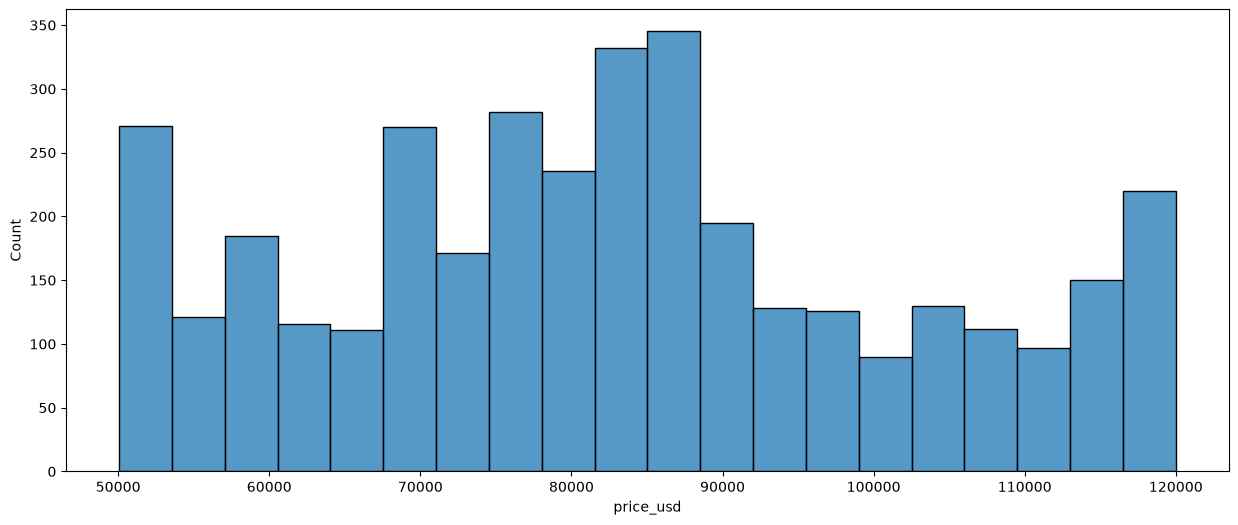

In [16]:
# Порядок распределения цен

plt.figure(figsize=(15,6)) # создаем "полотно", уточняем размер
sns.histplot(data=dfy, # какой датафрейм используем
             x='price_usd', # какую переменную отрисовываем
             bins = 20, # на сколько ячеек разбиваем
             log_scale = False); # захотели использовать логарифмический масштаб (для очень больших диапазонов)

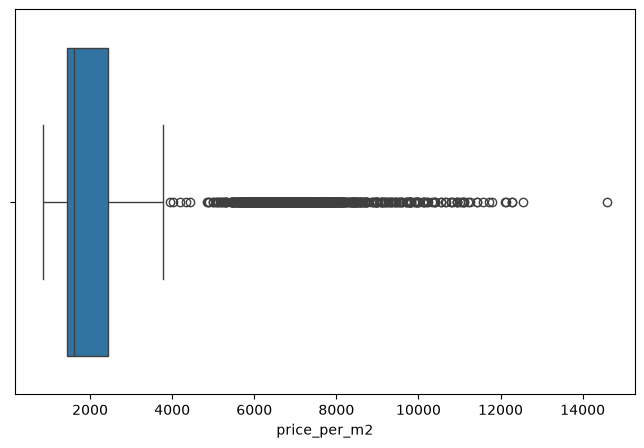

In [18]:
# разброс цен за м2

plt.figure(figsize=(8, 5))
sns.boxplot(data=dfy, x="price_per_m2")
plt.show()

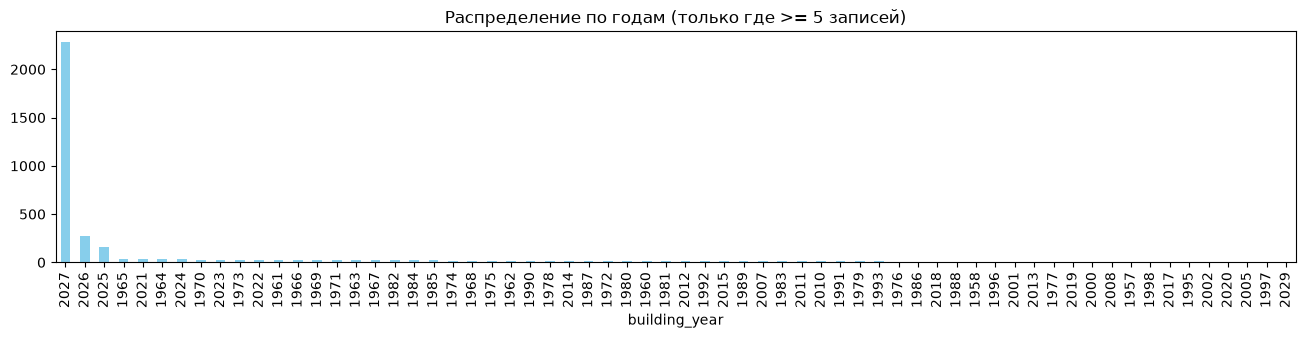

In [19]:
# График распределения по годам постройки

counts = dfy['building_year'].value_counts()

counts_filtered = counts[counts >= 5]

plt.figure(figsize=(16, 3))
counts_filtered.plot(kind='bar', color='skyblue')
plt.title('Распределение по годам (только где >= 5 записей)')
plt.show()

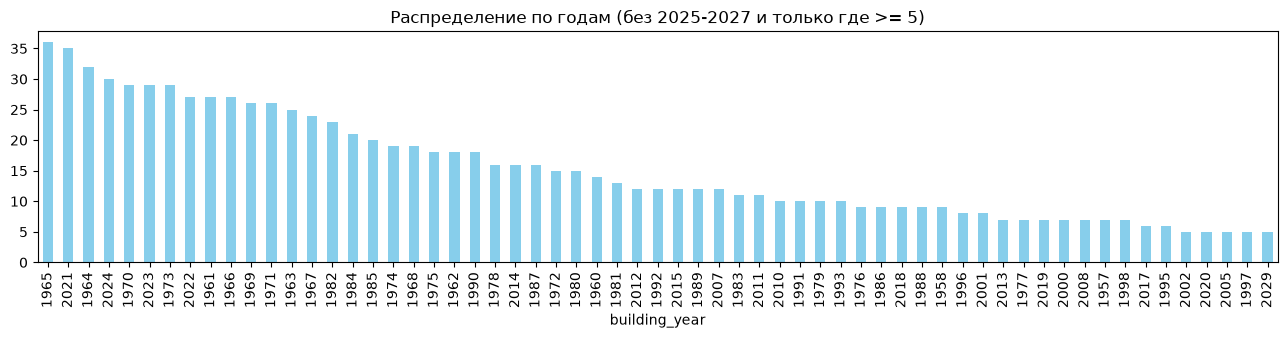

In [20]:
# Убираем новостройки 2025-27 гг

counts = dfy['building_year'].value_counts()

counts_filtered = counts[~counts.index.isin([2025, 2026, 2027])]
counts_filtered = counts_filtered[counts_filtered >= 5]

plt.figure(figsize=(16, 3))
counts_filtered.plot(kind='bar', color='skyblue')
plt.title('Распределение по годам (без 2025-2027 и только где >= 5)')
plt.show()

In [21]:
#Итоговое количество объектов после чистки

total_objects = counts_filtered.sum()

print("Сколько объектов попало (суммарно):", total_objects)

Сколько объектов попало (суммарно): 932


In [22]:
# Меняем содержание столбца агенства (все агенты теперь не делятся по кампаниям и появляется собственник)

dfy["agency_name"] = np.where(dfy["agency_name"].isna(), "owner", "agent")

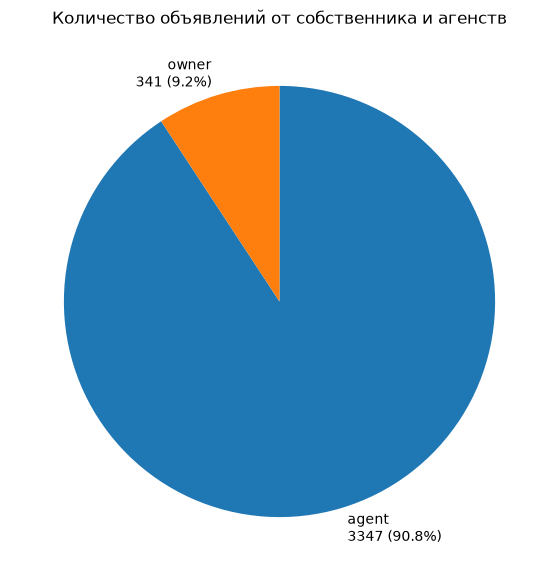

In [23]:
# Сравнение количества объявлений от агенств и собственника

plt.figure(figsize=(7, 7))

counts = dfy["agency_name"].value_counts(dropna=False)
total = counts.sum()

labels = counts.index.astype(str)
sizes = counts.values
percents = (sizes / total * 100).round(1)

plt.pie(
    sizes,
    labels=[f"{lab}\n{cnt} ({pct}%)" for lab, cnt, pct in zip(labels, sizes, percents)],
    startangle=90,
    counterclock=False
)

plt.title("Количество объявлений от собственника и агенств")
plt.show()

##Второй датасет

In [24]:
dfr.isna().sum() #пропущенные значения в таблице

id                        0
url                       0
price_amount              0
price_currency            0
price_usd                 0
price_byn                 0
number_of_rooms           0
floor                     0
number_of_floors          0
area_total                0
area_living               0
area_kitchen            197
address                  69
user_address              0
latitude                  0
longitude                 0
seller_type               0
resale                    0
photo                     0
created_at                0
last_time_up              0
auction_bid_amount      919
auction_bid_currency    919
dtype: int64

In [25]:
dfr = dfr.drop(columns=['auction_bid_amount', 'auction_bid_currency']) # дополнительно удаляем колонки с большим количеством незаполненных значений

In [26]:
print('Дубликатов =', dfr.duplicated().sum())

Дубликатов = 0


In [58]:
#dfr = dfy.drop_duplicates() # удаляем дубликаты

In [27]:
dfr.info() # информация о данных в датафрейме: сколько строк, какие данные в столбцах, сколько пропущенных значений

<class 'pandas.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                924 non-null    int64  
 1   url               924 non-null    str    
 2   price_amount      924 non-null    float64
 3   price_currency    924 non-null    str    
 4   price_usd         924 non-null    float64
 5   price_byn         924 non-null    float64
 6   number_of_rooms   924 non-null    int64  
 7   floor             924 non-null    int64  
 8   number_of_floors  924 non-null    int64  
 9   area_total        924 non-null    float64
 10  area_living       924 non-null    float64
 11  area_kitchen      727 non-null    float64
 12  address           855 non-null    str    
 13  user_address      924 non-null    str    
 14  latitude          924 non-null    float64
 15  longitude         924 non-null    float64
 16  seller_type       924 non-null    str    
 17  resale  

In [28]:
cat_columnsr = [] # создаем пустой список для имен колонок категориальных данных
num_columnsr = [] # создаем пустой список для имен колонок числовых данных

for column_name in dfr.columns: # смотрим на все колонки в датафрейме
    if (dfr[column_name].dtypes == object): # проверяем тип данных для каждой колонки
        cat_columnsr +=[column_name] # если тип объект - то складываем в категориальные данные
    else:
        num_columnsr +=[column_name] # иначе - числовые


# выводим результат
print('Категориальные данные:\t ',cat_columnsr, '\n Число столблцов = ',len(cat_columnsr))

print('Числовые данные:\t ',  num_columnsr, '\n Число столблцов = ',len(num_columnsr))

Категориальные данные:	  [] 
 Число столблцов =  0
Числовые данные:	  ['id', 'url', 'price_amount', 'price_currency', 'price_usd', 'price_byn', 'number_of_rooms', 'floor', 'number_of_floors', 'area_total', 'area_living', 'area_kitchen', 'address', 'user_address', 'latitude', 'longitude', 'seller_type', 'resale', 'photo', 'created_at', 'last_time_up'] 
 Число столблцов =  21


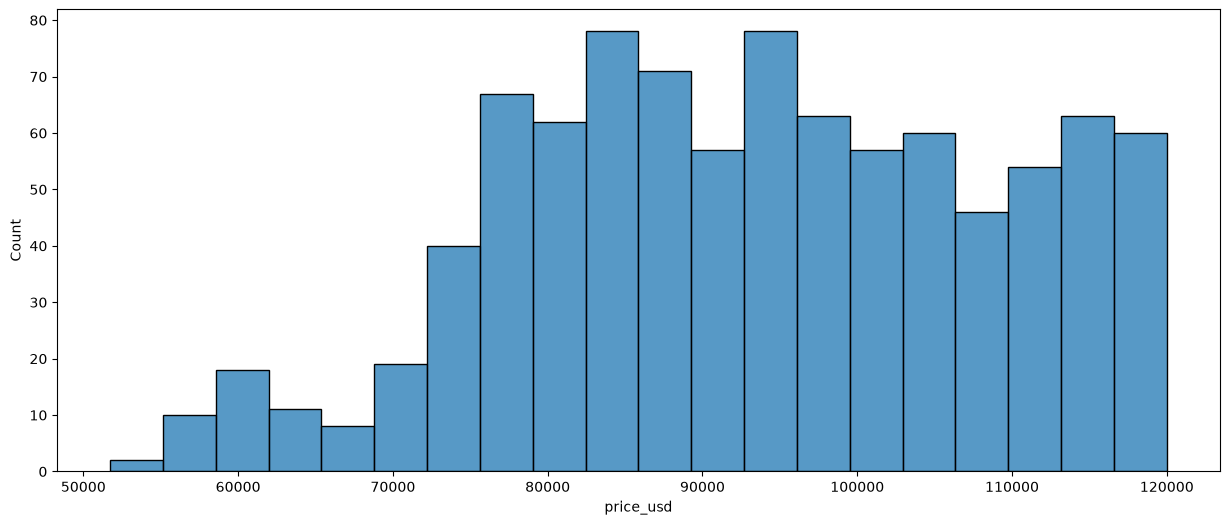

In [29]:
# Порядок распределения цен

plt.figure(figsize=(15,6)) # создаем "полотно", уточняем размер
sns.histplot(data=dfr, # какой датафрейм используем
             x='price_usd', # какую переменную отрисовываем
             bins = 20, # на сколько ячеек разбиваем
             log_scale = False); # захотели использовать логарифмический масштаб (для очень больших диапазонов)

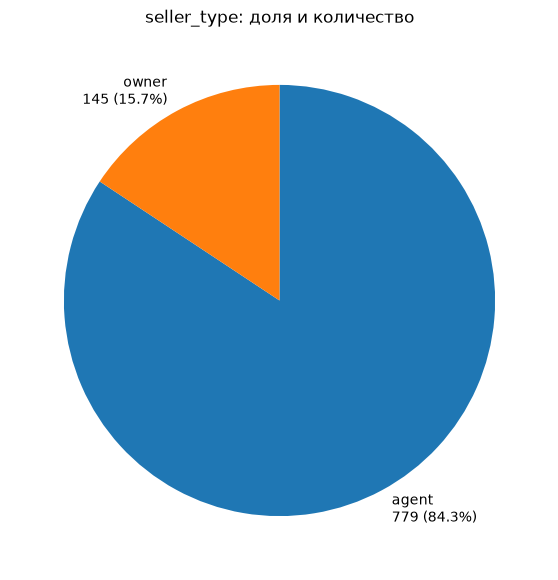

In [30]:
# Сравнение количества объявлений от агенств и собственника

plt.figure(figsize=(7, 7))

counts = dfr["seller_type"].value_counts(dropna=False)
total = counts.sum()

labels = counts.index.astype(str)
sizes = counts.values
percents = (sizes / total * 100).round(1)

plt.pie(
    sizes,
    labels=[f"{lab}\n{cnt} ({pct}%)" for lab, cnt, pct in zip(labels, sizes, percents)],
    startangle=90,
    counterclock=False
)

plt.title("seller_type: доля и количество")
plt.show()

In [32]:
# в данном датасете нет колонки "цена за м2", создадим её

dfr["price_per_m2"] = dfr["price_usd"] / dfr["area_total"].replace(0, np.nan)

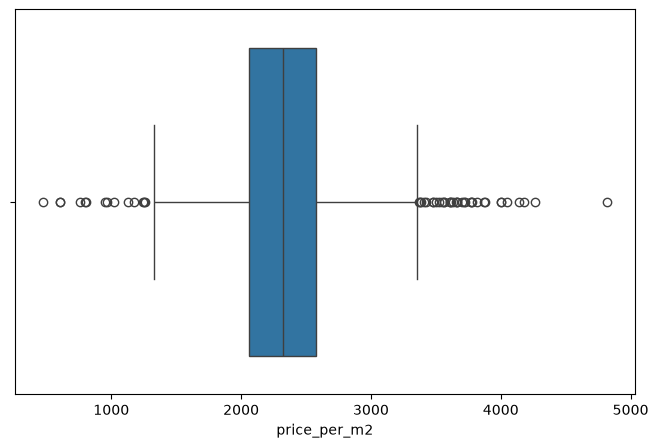

In [33]:
# разброс цен за м2

plt.figure(figsize=(8, 5))
sns.boxplot(data=dfr, x="price_per_m2")
plt.show()

#Приводим датасеты к общему виду

In [34]:
dfy.head(5)

,uuid,code,url,title,price,price_currency,price_usd,price_byn,price_per_m2,rooms,...,metro_station,building_year,repair_state,agency_name,contact_name,contact_phones,photo,created_at,updated_at,description
0,46f697b0-7ecc-11f1-9f5c-47ea628f0560,4180198,https://realt.by/sale-flats/object/46f697b0-7e...,Квартира 49 м² в ЖК «Вершина»,110250,840,110250,333903,2250,1,...,NaN,2026,8.0,owner,Строминвест-Ратомка,375445710196,https://cdn.realt.by/img/55/cc42facc-7ecb-11f1...,2026-07-13T18:05:25+03:00,2026-09-01T16:46:06+03:00,Квартира площадью 49 м2 в ЖК «Вершина» — удобн...
1,c97b4b00-9a14-11f1-b87f-d72a75202437,4208800,https://realt.by/sale-flats/object/c97b4b00-9a...,Просторная 1-комнатная квартира с ремонтом в Л...,107000,840,107000,324060,2383,1,...,NaN,2017,2.0,owner,Сергей,375293337744,https://cdn.realt.by/img/55/817d3e8a-9a0f-11f1...,2026-08-17T11:22:29+03:00,2026-09-15T09:49:15+03:00,"Квартира с качественным современным ремонтом, ..."
2,22973e80-5819-11f1-98bf-7d269c16dd44,4134843,https://realt.by/sale-flats/object/22973e80-58...,"Просторная двушка на Руссиянова, 56 с огромным...",320000,933,105659,320000,7547,2,...,Уручье,2026,7.0,owner,Алекс,375257853093,https://cdn.realt.by/img/55/0f90677c-7a9b-11f1...,2026-05-25T12:07:20+03:00,2026-09-10T21:52:35+03:00,"Уникальное, единственное в своем роде предложе..."
3,b06180d0-867d-11f1-86e8-8f5431bc91bb,4188681,https://realt.by/sale-flats/object/b06180d0-86...,Уютная большая 2-комнатная сталинка по улице И...,334000,933,110282,334000,6122,2,...,Пролетарская,1937,2.0,agent,Марина,375445089755,https://cdn.realt.by/img/55/6d9c0d4c-867d-11f1...,2026-07-23T13:03:01+03:00,2026-09-14T19:56:47+03:00,Прекрасный вариант сталинки для покупки! 2-ком...
4,2b88d620-6408-11f1-82b6-7969fefbc065,4148777,https://realt.by/sale-flats/object/2b88d620-64...,Продается многофункциональная студия бизнес-ап...,172630,933,57000,172630,6989,1,...,Аэродромная (2024),2025,7.0,agent,Анна,375447679053,https://cdn.realt.by/img/55/9d082f40-6407-11f1...,2026-06-09T16:36:07+03:00,2026-09-16T18:45:59+03:00,Продаются многофункциональные бизнес-апартамен...


In [67]:
dfr.head(5)

,price_amount,price_currency,price_usd,price_byn,number_of_rooms,floor,number_of_floors,area_total,area_living,area_kitchen,address,user_address,latitude,longitude,seller_type,created_at,last_time_up,price_per_m2
0,291403.0,BYN,96217.06,291403.00,1,3,22,31.3,24.2,NaN,"Минск, Братская ул. 8","Минск, Братская ул. 8",53.869700,27.552600,agent,2026-08-22T14:55:00+03:00,2026-09-15T11:15:09+03:00,3074.027476
1,118000.0,USD,118000.00,357374.80,2,6,10,53.3,31.8,9.2,"Минск, улица Сергея Есенина, 117","Минск, улица Сергея Есенина, 117",53.863269,27.435688,owner,2026-09-14T20:27:53+03:00,2026-09-14T20:27:53+03:00,2213.883677
2,74900.0,USD,74900.00,226842.14,1,2,9,34.0,17.0,7.0,"Минск, улица Мирошниченко, 16 к2","Минск, улица Мирошниченко, 16 к2",53.960433,27.619846,owner,2026-07-07T10:05:08+03:00,2026-09-16T14:12:06+03:00,2202.941176
3,330000.0,BYN,108961.24,330000.00,2,3,9,58.5,30.0,9.0,"Боровлянский сельский Совет, Боровляны, улица ...","Боровлянский сельский Совет, Боровляны, улица ...",53.987977,27.672890,owner,2026-08-19T12:17:48+03:00,2026-09-15T07:07:16+03:00,1862.585299
4,93000.0,USD,93000.00,281659.80,2,10,15,44.2,40.2,NaN,"Minsk, вуліца Міхаіла Савіцкага","Минск, улица Михаила Савицкого",53.863018,27.543949,owner,2026-09-03T16:41:48+03:00,2026-09-14T19:34:26+03:00,2104.072398


In [68]:
# Удаляем столбцы, которых нет в одном из датасетов

dfy = dfy.drop(columns=['price', 'price_byn', 'street_name', 'house_number', 'repair_state', 'metro_station', 'building_year'])
dfr = dfr.drop(columns=['price_amount', 'price_currency', 'price_byn', 'user_address', 'latitude', 'longitude'])

In [69]:
# переименовываем колонки

dfr = dfr.rename(columns={
    "number_of_rooms": "rooms",
    "seller_type": "agency_name",
    "last_time_up": "updated_at"
})

# задаём новый порядок
new_order = [
    "price_usd",
    "price_per_m2",
    "rooms",
    "area_total",
    "area_living",
    "area_kitchen",
    "address",
    "agency_name",
    "created_at",
    "updated_at"
]

# переставляем колонки
dfr = dfr[new_order]

Получили два одинаковых датасета по внешнему виду

In [70]:
dfy.head(1)

,price_usd,price_per_m2,rooms,area_total,area_living,area_kitchen,address,agency_name,created_at,updated_at
0,110250,2250,1,49.0,49.0,NaN,Минск Лосика ул. 47,owner,2026-07-13T18:05:25+03:00,2026-09-01T16:46:06+03:00


In [71]:
dfr.head(1)

,price_usd,price_per_m2,rooms,area_total,area_living,area_kitchen,address,agency_name,created_at,updated_at
0,96217.06,3074.027476,1,31.3,24.2,NaN,"Минск, Братская ул. 8",agent,2026-08-22T14:55:00+03:00,2026-09-15T11:15:09+03:00
